# zhong2025 exploration

Zhong et al. 2025, *Unsupervised pretraining in biological neural networks*.
Two-photon mesoscope imaging of visual cortex while head-fixed mice run through virtual reality corridors.

## Setup

In [23]:
import os
import numpy as np
import matplotlib.pyplot as plt

DATA = 'data'
BEH = os.path.join(DATA, 'beh')            # behavior, one file per experiment type
SPK = os.path.join(DATA, 'spk')            # deconvolved calcium traces, one file per session
RETINO = os.path.join(DATA, 'retinotopy')  # visual area of each neuron, one file per mouse and date

SEC_PER_DAY = 24 * 60 * 60   # the times are MATLAB datenums, so in days
N_FRAMES = 40                # trial length, about 12.6 s, past the 75th percentile of the traversals

## Subjects and sessions

In [24]:
def list_sessions():
    """Every recording once, as {subject: [(session_id, beh_file, beh_key)]}."""
    # the master index of every recording, grouped by experiment type
    exp_info = np.load(os.path.join(BEH, 'Imaging_Exp_info.npy'), allow_pickle=True).item()
    sessions, seen = {}, set()
    for exp_type, db in exp_info.items():
        for entry in db:
            # a recording is one mouse on one date in one block, and names the spike file
            session_id = '%s_%s_%s' % (entry['mname'], entry['datexp'], entry['blk'])
            # the same recording is listed under several experiment types, so keep only the first
            if session_id in seen:
                continue
            seen.add(session_id)
            # the behavior file keys a swap session by its stimulus type as well
            beh_key = session_id + ('_' + entry['stimtype'] if 'stimtype' in entry else '')
            record = (session_id, 'Beh_%s.npy' % exp_type, beh_key)
            sessions.setdefault(entry['mname'], []).append(record)
    return {subject: sorted(sessions[subject]) for subject in sorted(sessions)}


sessions = list_sessions()
print(len(sessions), 'subjects,', sum(len(s) for s in sessions.values()), 'sessions')
sessions['TX88']

19 subjects, 89 sessions


[('TX88_2022_06_13_2',
  'Beh_unsup_train1_before_learning.npy',
  'TX88_2022_06_13_2'),
 ('TX88_2022_06_17_2',
  'Beh_unsup_train1_after_learning.npy',
  'TX88_2022_06_17_2'),
 ('TX88_2022_06_20_1', 'Beh_unsup_test1.npy', 'TX88_2022_06_20_1'),
 ('TX88_2022_07_15_1',
  'Beh_unsup_train2_after_learning.npy',
  'TX88_2022_07_15_1'),
 ('TX88_2022_07_19_1', 'Beh_unsup_test2.npy', 'TX88_2022_07_19_1'),
 ('TX88_2022_07_22_1', 'Beh_unsup_test3.npy', 'TX88_2022_07_22_1_swap1')]

## One session

In [25]:
def load_beh(beh_file, beh_key):
    """Behavior of one session."""
    return np.load(os.path.join(BEH, beh_file), allow_pickle=True).item()[beh_key]


session_id, beh_file, beh_key = sessions['TX60'][2]
beh = load_beh(beh_file, beh_key)
frame_time = (beh['ft'] - beh['ft'][0]) * SEC_PER_DAY

print('%s: %d trials, %d frames, %.0f s at %.2f Hz'
      % (session_id, beh['ntrials'], frame_time.size, frame_time[-1], frame_time.size / frame_time[-1]))

TX60_2021_06_07_1: 485 trials, 22476 frames, 7076 s at 3.18 Hz


In [26]:
# every field is indexed by trial or by neural frame, so the streams need no realignment
kinds = {beh['ntrials']: 'trial', frame_time.size: 'frame'}
for kind in ['trial', 'frame']:
    print(kind, [name for name, value in beh.items()
                 if isinstance(value, np.ndarray) and kinds.get(len(value)) == kind])

trial ['trInd', 'trInd_odd', 'trInd_even', 'Trial_start_time', 'Trial_end_time', 'Gray_space_time', 'SoundPos', 'SoundTime', 'SoundTimeDelay', 'RewTime', 'RewPos', 'isRew', 'WallType', 'WallIsProbe', 'WallName', 'run_pos', 'RewardFr', 'StartFr', 'GrayFr', 'EndFr', 'SoundFr', 'SoundDelayFr', 'SoundDelPos', 'TrialStim']
frame ['ft', 'ft_trInd', 'ft_trInd_odd', 'ft_trInd_even', 'ft_PosCum', 'ft_Pos', 'ft_move', 'ft_isMoving', 'ft_GraySpc', 'ft_CorrSpc', 'ft_WallID', 'ft_RunCum', 'ft_RunSpeed', 'RunFr', 'BefCueFr', 'AftCueFr']


## Per trial variables

In [27]:
# the wall of a corridor is one of four textures, shown as several crops and spatial shuffles
TEXTURE = {'circle1': 'circle', 'circle2': 'circle', 'circle3': 'circle',
           'leaf1': 'leaf', 'leaf2': 'leaf', 'leaf3': 'leaf',
           'leaf1_swap1': 'leaf', 'leaf1_swap2': 'leaf',
           'rock1': 'rock', 'rock2': 'rock',
           'wood1': 'wood', 'wood2': 'wood', 'wood5': 'wood',
           'wood1_swap1': 'wood', 'wood1_swap2': 'wood'}

STIMULUS = ['circle', 'leaf', 'rock', 'wood']
REWARD = ['not available', 'available']

In [28]:
# a session shows only a few of the stimuli, so check the map against the whole dataset
names = set()
for name in sorted(os.listdir(BEH)):
    if name.startswith('Beh_'):
        for entry in np.load(os.path.join(BEH, name), allow_pickle=True).item().values():
            names.update(entry['WallName'])
print(len(names), 'stimuli, not in the map:', sorted(names - set(TEXTURE)))

15 stimuli, not in the map: []


In [29]:
stimulus = np.array([STIMULUS.index(TEXTURE[name]) for name in beh['WallName']])
reward = beh['isRew'].astype(int)

# reward availability is a property of the corridor, so it is constant within a stimulus
for name in np.unique(beh['WallName']):
    trials = beh['WallName'] == name
    print('%-8s %-7s %4d trials, reward available on %d'
          % (name, TEXTURE[name], trials.sum(), reward[trials].sum()))

circle1  circle   189 trials, reward available on 0
circle2  circle    64 trials, reward available on 0
leaf1    leaf     175 trials, reward available on 175
leaf2    leaf      57 trials, reward available on 0


## Time varying variables

A corridor takes 21 frames to cross at the speed the virtual reality moves, but a mouse can stop
part way, so the traversals run from 11 to 5607 frames. Each one is cut to `N_FRAMES` and padded
out to it with a symbol of its own, which keeps the padding out of the bins of the other values.

In [30]:
# the last value of each is the padding, so a padded bin is never confused with a real one
LICKING = ['no lick', 'lick', 'none']
POSITION = ['0-1 m', '1-2 m', '2-3 m', '3-4 m', 'none']
SPEED = ['lowest', 'low', 'high', 'highest', 'none']


def trial_frames(beh, trial):
    """Neural frames of one trial, from corridor entry to the grey space."""
    # the authors label every frame with its trial and whether it is inside the texture
    return np.flatnonzero((beh['ft_trInd'] == trial) & beh['ft_CorrSpc'])[:N_FRAMES]


def fixed_length(values, frames, names):
    """One trial of a frame level variable, padded out to the window with its own symbol."""
    return np.pad(values[frames], (0, N_FRAMES - frames.size), constant_values=len(names) - 1)

In [31]:
def quartiles(values):
    """Split into four bins of a quarter of the data each."""
    # a quarter or more of the frames can sit at exactly zero speed, and no threshold can
    # cut a tie like that into equal parts, so the split is on rank rather than on value
    rank = np.empty(values.size, dtype=int)
    rank[np.argsort(values, kind='stable')] = np.arange(values.size)
    return rank * 4 // values.size

In [32]:
# the frames the dataset keeps, which the quartiles are taken over
kept = np.concatenate([trial_frames(beh, trial) for trial in range(beh['ntrials'])])

# licking comes as the frame number of each lick, so make it a flag per frame
licking = np.zeros(frame_time.size, dtype=int)
licking[beh['LickFr'].astype(int)] = 1

# position bins are 10 decimeters, the 1 m the task asks for
position = np.clip(beh['ft_Pos'] // 10, 0, 3).astype(int)

speed = np.zeros(frame_time.size, dtype=int)
speed[kept] = quartiles(beh['ft_RunSpeed'][kept])

for name, value in [('licking', licking), ('position', position), ('speed', speed)]:
    print('%-9s' % name, np.round(np.bincount(value[kept]) / kept.size, 3))

licking   [0.829 0.171]
position  [0.268 0.222 0.267 0.243]
speed     [0.25 0.25 0.25 0.25]


In [33]:
def trial_output(beh, trial):
    """Stimulus, licking, position and speed over the trial window."""
    frames = trial_frames(beh, trial)
    return np.stack([np.full(N_FRAMES, stimulus[trial]),
                     fixed_length(licking, frames, LICKING),
                     fixed_length(position, frames, POSITION),
                     fixed_length(speed, frames, SPEED)])


trial_output(beh, 0)

array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
       [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 3, 3, 3,
        3, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4],
       [0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 3, 3, 2, 2, 2,
        1, 1, 0, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4]])

In [34]:
def trial_input(beh, trial):
    """Time to the sound cue, time since corridor entry and reward availability."""
    frames = trial_frames(beh, trial)
    # the frame grid is regular, so the time axis keeps counting through the padding
    period = np.median(np.diff(frame_time))
    time = np.concatenate([frame_time[frames],
                           frame_time[frames[-1]] + period * np.arange(1, N_FRAMES - frames.size + 1)])
    # both events fall between frames, so they are interpolated onto the time axis
    index = np.arange(frame_time.size)
    return np.stack([np.interp(beh['SoundFr'][trial], index, frame_time) - time,
                     time - np.interp(beh['StartFr'][trial], index, frame_time),
                     np.full(N_FRAMES, reward[trial])])


np.round(trial_input(beh, 0), 1)

array([[ 4.3,  4.1,  3.7,  3.4,  3.1,  2.8,  2.5,  2.2,  1.9,  1.5,  1.2,
         0.9,  0.6,  0.3, -0. , -0.3, -0.7, -1. , -1.3, -1.6, -1.9, -2.2,
        -2.5, -2.9, -3.2, -3.5, -3.8, -4.1, -4.4, -4.7, -5.1, -5.4, -5.7,
        -6. , -6.3, -6.6, -7. , -7.3, -7.6, -7.9],
       [ 0.1,  0.4,  0.7,  1. ,  1.3,  1.6,  2. ,  2.3,  2.6,  2.9,  3.2,
         3.5,  3.8,  4.2,  4.5,  4.8,  5.1,  5.4,  5.7,  6. ,  6.4,  6.7,
         7. ,  7.3,  7.6,  7.9,  8.2,  8.6,  8.9,  9.2,  9.5,  9.8, 10.1,
        10.4, 10.8, 11.1, 11.4, 11.7, 12. , 12.3],
       [ 0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,
         0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,
         0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,
         0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ]])

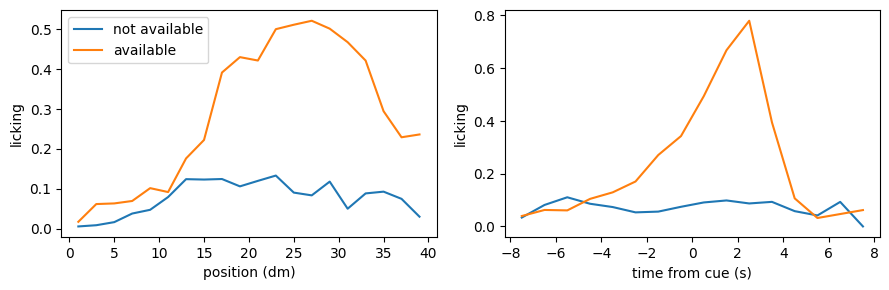

In [35]:
# licking should rise with position and around the cue, in the rewarded corridor only
fig, ax = plt.subplots(1, 2, figsize=(9, 3))
for rewarded in [0, 1]:
    trials = np.flatnonzero(reward == rewarded)
    frames = np.concatenate([trial_frames(beh, trial) for trial in trials])
    from_cue = -np.concatenate([trial_input(beh, trial)[0, :trial_frames(beh, trial).size]
                                for trial in trials])

    edges = np.arange(0, 41, 2)
    ax[0].plot(edges[:-1] + 1, [licking[frames][(beh['ft_Pos'][frames] >= a)
                                                & (beh['ft_Pos'][frames] < b)].mean()
                                for a, b in zip(edges, edges[1:])], label=REWARD[rewarded])

    edges = np.arange(-8, 9)
    ax[1].plot(edges[:-1] + 0.5, [licking[frames][(from_cue >= a) & (from_cue < b)].mean()
                                  for a, b in zip(edges, edges[1:])])

ax[0].set(xlabel='position (dm)', ylabel='licking')
ax[1].set(xlabel='time from cue (s)', ylabel='licking')
ax[0].legend()
plt.tight_layout()